In [1]:
import sympy as sp
from control import tf, step_response, poles, zeros, pzmap
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Define variables symbolically
s = sp.symbols('s')
X = sp.symbols('X')
Y = sp.symbols('Y')

# Set up the equations according to the given system
A = 2*s**2 * Y + s * Y
B = s * X + X

# Solve for Y in terms of X and s
# Mathematically: Y(2s^2 + s) = X(s + 1) -> Y/X = (s + 1) / (2s^2 + s)
tf_expr = sp.solve(sp.Eq(A, B), Y)[0] / X
tf_simplified = sp.simplify(tf_expr)

print(f"Calculated Transfer Function G(s): {tf_simplified}")

Calculated Transfer Function G(s): (s + 1)/(s*(2*s + 1))


In [ ]:
# Convert the symbolic transfer function to numerical coefficients for control library
num_coeffs = [float(c) for c in sp.Poly(sp.numer(tf_simplified), s).all_coeffs()]
den_coeffs = [float(c) for c in sp.Poly(sp.denom(tf_simplified), s).all_coeffs()]

sys = tf(num_coeffs, den_coeffs)
print(sys)


<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    s + 1
  ---------
  2 s^2 + s


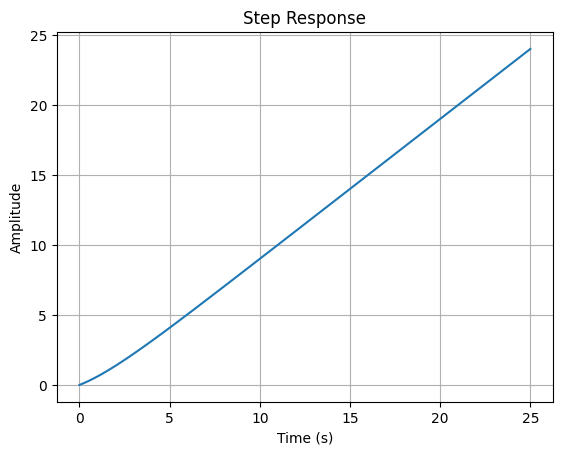

In [ ]:
# Calculate and plot the step response
t, y = step_response(sys)

plt.plot(t, y)
plt.title('Step Response')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()


Poles: [-0.5+0.j  0. +0.j]
Zeros: [-1.+0.j]


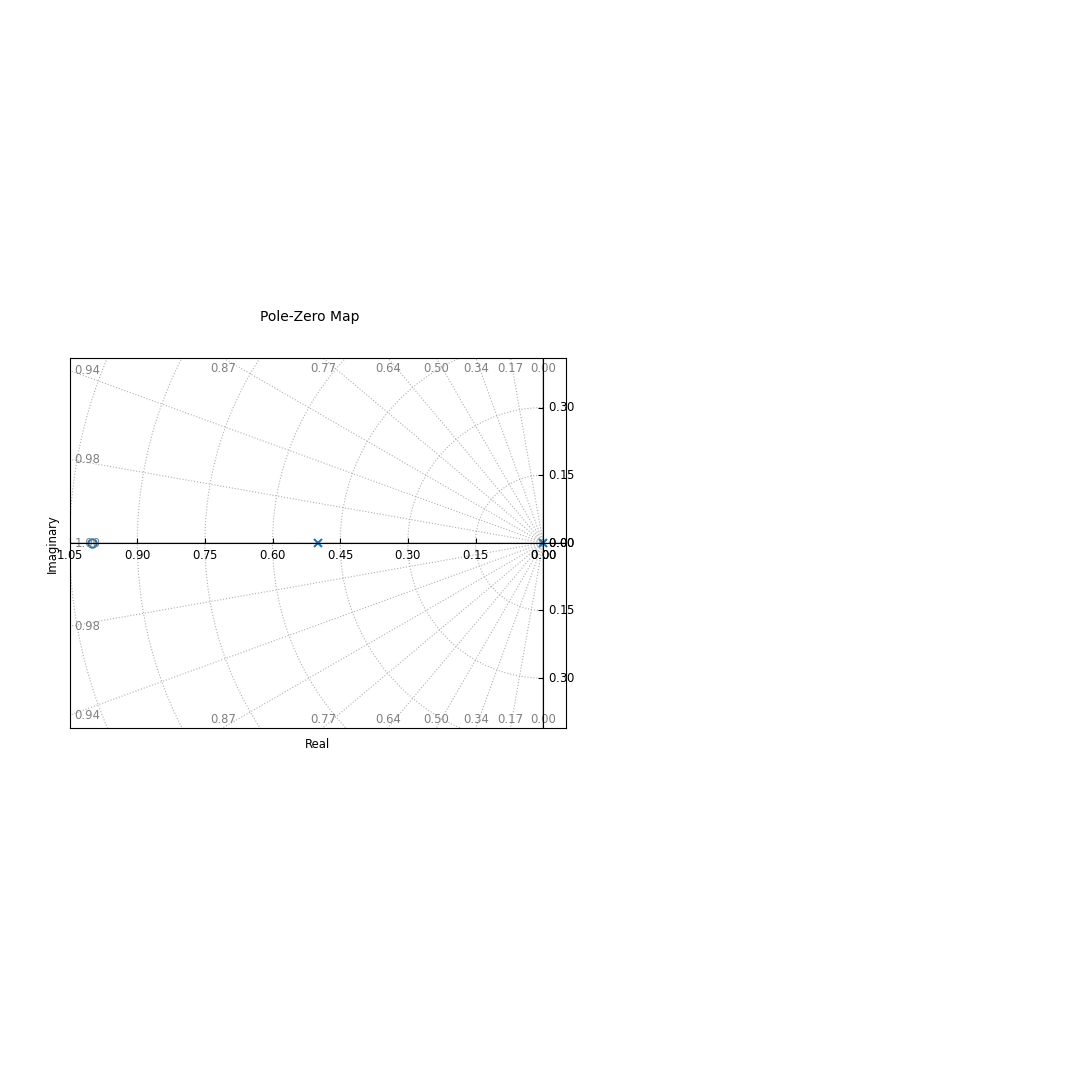

In [ ]:
# Calculate and print poles and zeros
print(f"Poles: {poles(sys)}")
print(f"Zeros: {zeros(sys)}")

# Plot the pole-zero map
pzmap(sys, grid=True, title='Pole-Zero Map')
plt.show()